In [2]:
from pathlib import Path
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
import os
import matplotlib.pyplot as plt
import cv2
import torch.nn as nn
import optuna
import random
import numpy as np
import matplotlib.pyplot as plt
from transfer_learning_block import (
    load_base_model,
    prepare_transfer_components,
    train_model_components,
    get_predictions_components,
    save_transfer_head,
    print_transfer_summary,
    get_device
)

In [3]:
DATASET_DIR = Path("../dataset/")
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
storage_name = "sqlite:///optuna_study4.db"
EPOCHS = 10

Using cpu device


## 2 ) Visualize the dataset

Class: asteroid


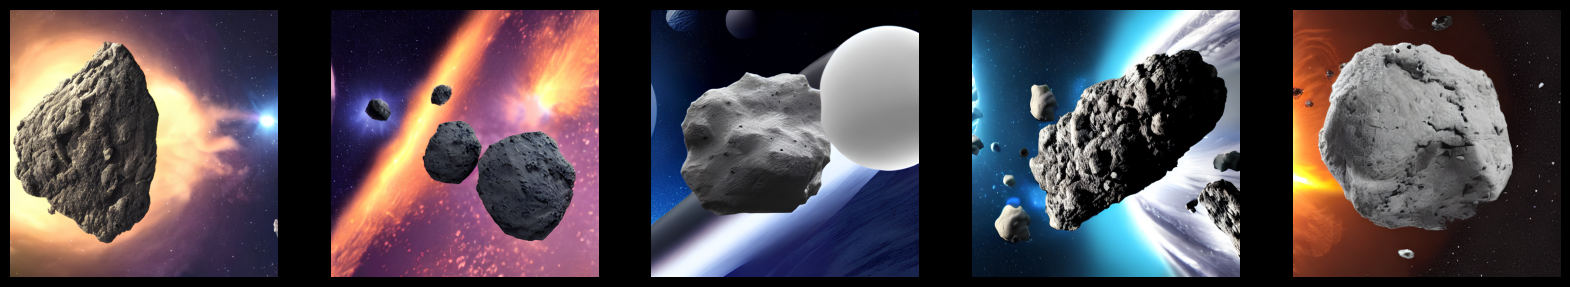

Class: black_hole


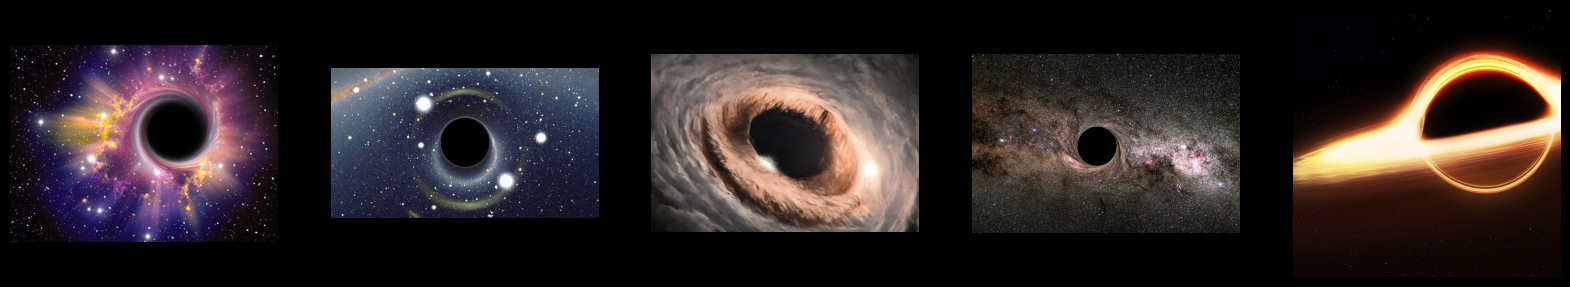

Class: earth


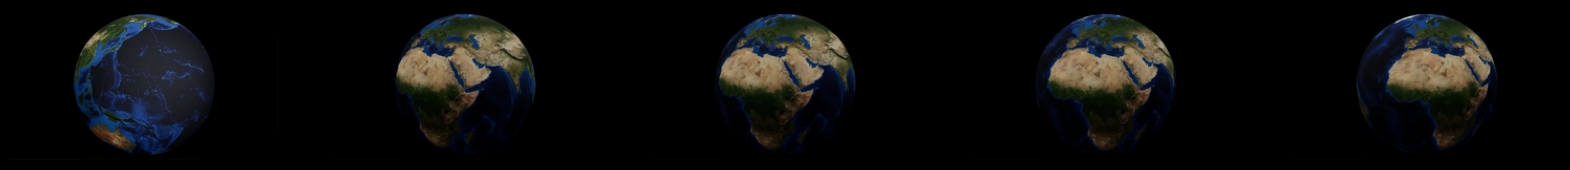

Class: galaxy


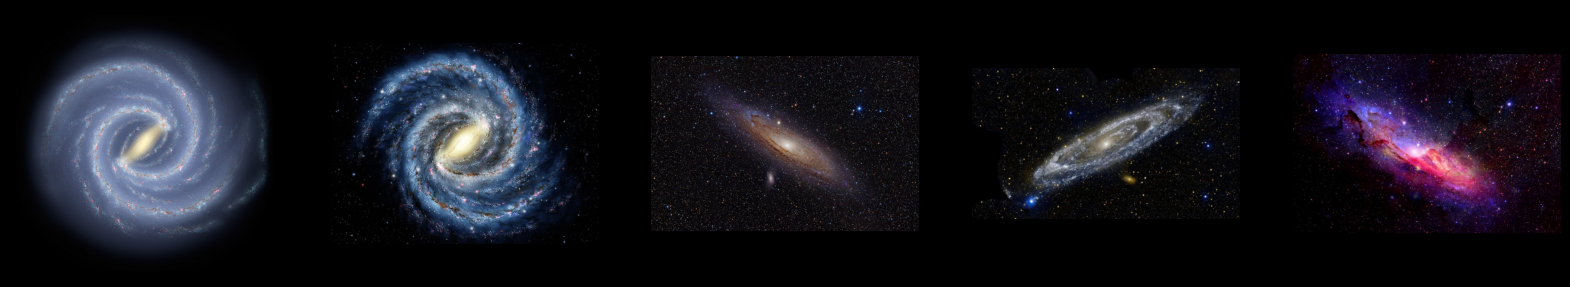

Class: jupiter


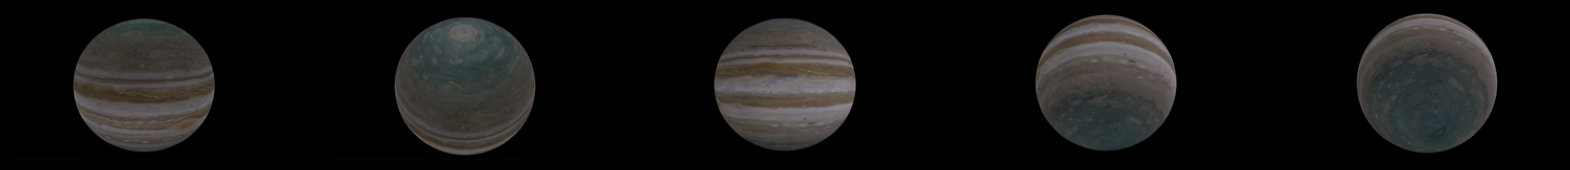

Class: mars


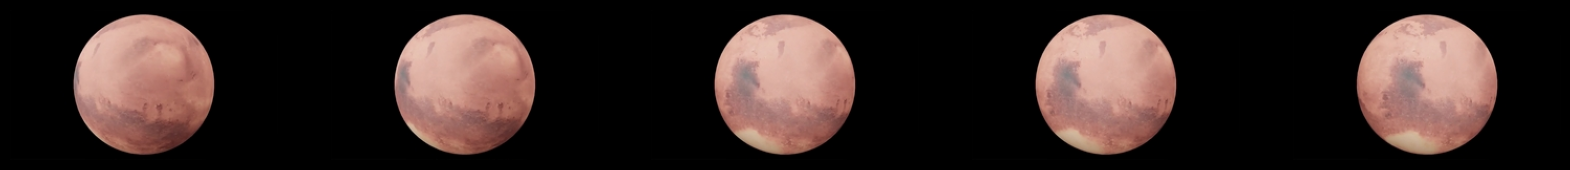

Class: mercury


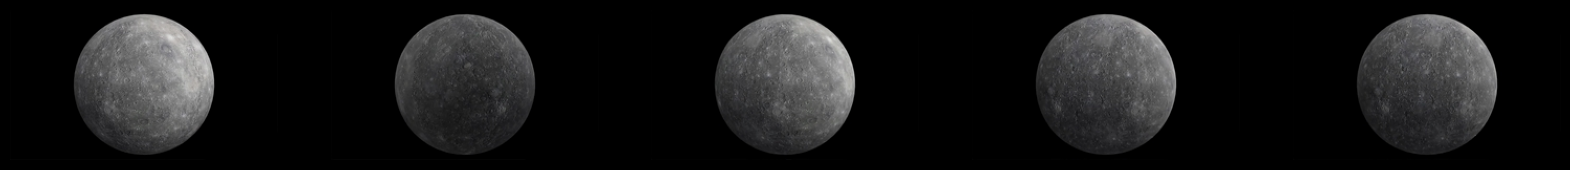

Class: neptune


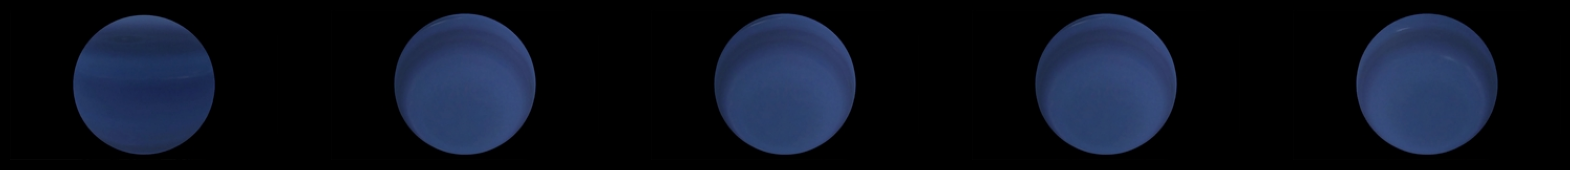

Class: pluto


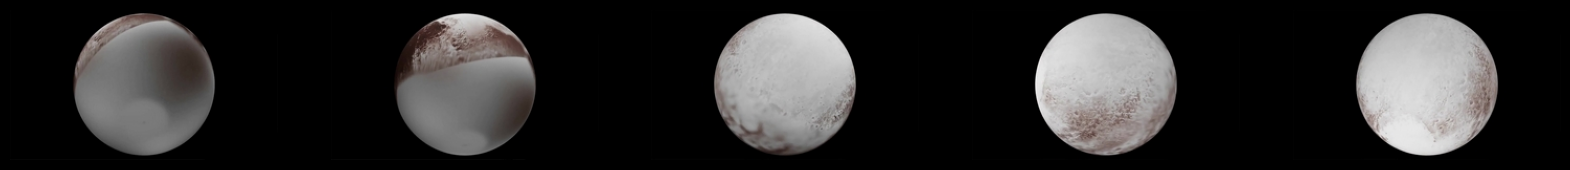

Class: saturn


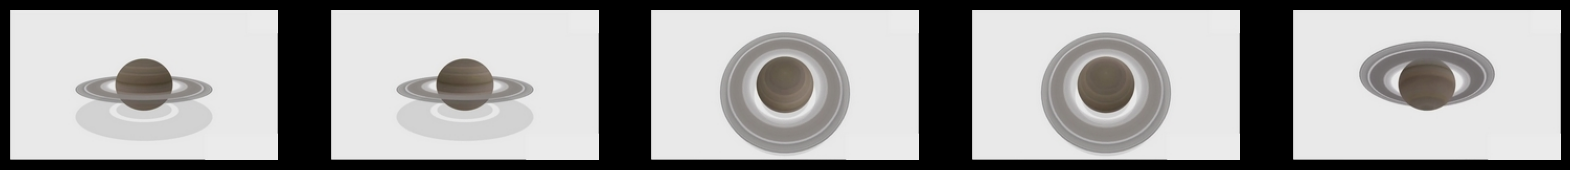

Class: uranus


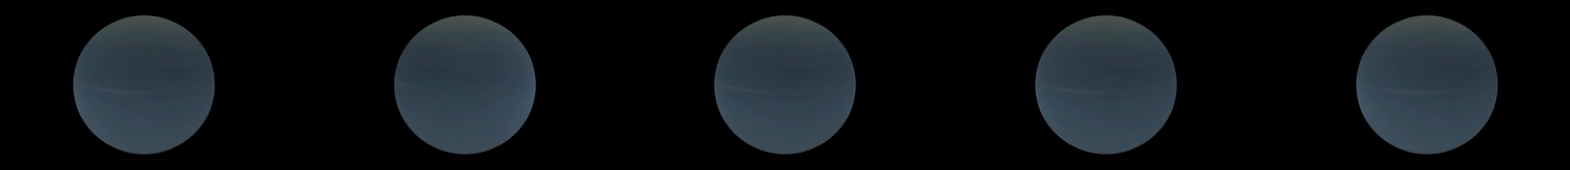

Class: venus


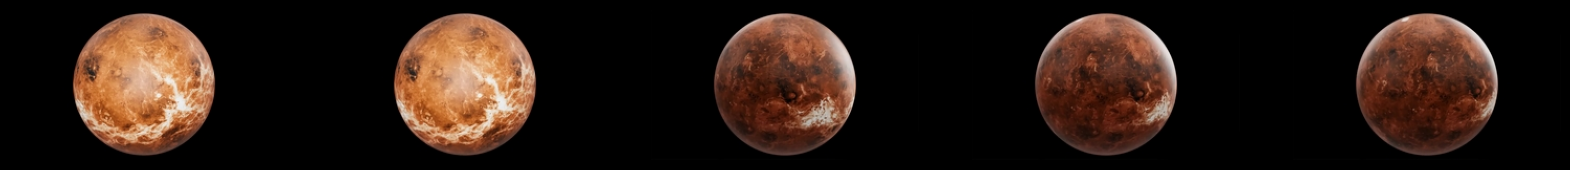

In [4]:
for class_ in os.listdir(DATASET_DIR / "training"):
    class_path = DATASET_DIR / "training" / class_

    print(f"Class: {class_}")
    # Lista de imágenes de esa clase
    images = os.listdir(class_path)[:5]

    fig = plt.figure(figsize=(20, 5))
    columns, rows = 5, 1

    for i in range(len(images)):
        img_path = class_path / images[i]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        fig.add_subplot(rows, columns, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

## 2 ) Loading the dataset and creating a dataloader

In [5]:
def data_loader(data_path: Path, batch_size , transform : transforms.Compose):
    dataset_transformed = ImageFolder(data_path, transform=transform)
    dataloader = torch.utils.data.DataLoader(dataset_transformed, batch_size=batch_size, shuffle=True)
    return dataloader

## 4 ) CNN Network Architecture : AlexNet

In [6]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=12):
        super(AlexNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(in_channels=96, out_channels=256 , kernel_size=5, stride=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, stride=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, stride=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, stride=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2), # Output is [Batch, 256, 6, 6]
            # Allows CNNs to accept images of varying dimensions without changing the network architecture.It automatically calculates the necessary kernel size and stride
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten() # Output is [Batch, 9216]
        )
        self.classifier = nn.Sequential(
            nn.Linear(in_features=256,out_features= 4096),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=4096, out_features= 4096),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=4096, out_features= num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 5 ) Train

In [7]:
def train(model, train_loader, optimizer, loss_fn, device):
    model.train()
    for data, target in train_loader:
        # Send the data to the device in our case GPU
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()

        # model(data) returns [batch_size, 1].
        # targets are [batch_size], so we remove only the last dimension to match shapes for MSELoss: [batch_size, 1] -> [batch_size] we apply the squeeze function.
        prediction = model(data).squeeze()
        loss = loss_fn(prediction, target)
        loss.backward()

        # Update the model parameters using the computed gradients and the learning rate.
        optimizer.step()

 ## 6 ) Validate

In [8]:
def validation(model, val_loader, loss_fn, device) -> float:
    model.eval()
    total = 0.0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            prediction = model(data).squeeze()
            total += loss_fn(prediction, target).item()
    return total / len(val_loader)

## 5 ) Optuna Optimization

In [9]:
def objective(trial):
    loss_fn = nn.CrossEntropyLoss()
    model = AlexNet()

    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128, 256])

    # Hyperparameters to image transformation
    #Image size
    image_size = trial.suggest_categorical("image_size", [224 , 299])

    # Rotation degrees
    rot_degrees = trial.suggest_int("rot_degrees", 0, 360)

    #Probability to flip horizontally
    h_flip = trial.suggest_int("h_flip", 0, 1)

    #Brightness ( 1.0 is the original )
    brightness = trial.suggest_int("brightness", 0.8, 1.2)

    #Randndom crop ( how much are we willing to crop the image randomly )
    crop_scale = trial.suggest_int("crop_scale", 0.7, 1)

    #Find the best normalization transformation
    norm_strategy = trial.suggest_categorical("norm_strategy", ["imagenet", "custom", "simple"])

    if norm_strategy == "imagenet":
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]
    elif norm_strategy == "custom":
        # Optuna search for you mean values and std for our data
        m = trial.suggest_float("m_custom", 0.0, 1.0)
        s = trial.suggest_float("s_custom", 0.1, 0.5)
        mean, std = [m, m, m], [s, s, s]
    else: # "simple" [0, 1]
        mean, std = [0.0, 0.0, 0.0], [1.0, 1.0, 1.0]

    transform = transforms.Compose([
        transforms.RandomRotation(degrees=rot_degrees),
        transforms.RandomResizedCrop(size=(image_size,image_size),scale=(crop_scale,crop_scale,1)),
        transforms.RandomHorizontalFlip(p=h_flip),
        transforms.ColorJitter(brightness=brightness),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    train_loder = data_loader(DATASET_DIR / "training", batch_size=batch_size, transform=transform)
    validation_loader = data_loader(DATASET_DIR / "validation", batch_size=batch_size, transform=transform)

    #Generate the best Optimizer
    #Suggest best lr
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)

    #Get optimizer name
    optimizer = trial.suggest_categorical("optimizer", ["Adam", "SGD"])

    momentum = trial.suggest_float("momentum", 0.8, 1)

    #Penalizes large weights , prevents overfitting
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-1, log=True)

    if optimizer == "Adam":
        scaling = trial.suggest_float("scaling", 0.9, 1)
        optimizer = torch.optim.Adam(
            params= model.parameters(),
            betas=(momentum,scaling),
            lr=lr,
            weight_decay=weight_decay,
        )
    else:
        optimizer = torch.optim.SGD(
            params=model.parameters(),
            momentum= momentum,
            lr=lr,
            weight_decay=weight_decay)

    for _ in range(EPOCHS):
        train(model, train_loder, optimizer, loss_fn, device)

    return validation(model,validation_loader,loss_fn, device)

In [10]:
study = optuna.create_study(
    study_name="study7",
    storage=storage_name,
    direction="maximize",
    load_if_exists=True
)

study.optimize(objective, n_trials=100)


[I 2026-05-05 17:06:55,801] Using an existing study with name 'study7' instead of creating a new one.
[W 2026-05-05 17:06:58,195] Trial 1 failed with parameters: {'batch_size': 128, 'image_size': 299, 'rot_degrees': 181, 'h_flip': 1, 'brightness': 0, 'crop_scale': 0, 'norm_strategy': 'custom', 'm_custom': 0.9623978615263886, 's_custom': 0.11058139513141595, 'lr': 0.0003386958325001383, 'optimizer': 'SGD', 'momentum': 0.8991687251289435, 'weight_decay': 9.416274192530664e-05} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\lucas.stille\AppData\Roaming\Python\Python312\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\lucas.stille\AppData\Local\Temp\ipykernel_29740\1039291990.py", line 77, in objective
    train(model, train_loder, optimizer, loss_fn, device)
  File "C:\Users\lucas.stille\AppData\Local\Temp\ipykernel_29740\347648966

KeyboardInterrupt: 

In [1]:
def get_transform(best_params):
    # Si recibe un objeto Optuna study, extrae .best_params
    if hasattr(best_params, "best_params"):
        best_params = best_params.best_params

    image_size = best_params["image_size"]
    rot_degrees = best_params["rot_degrees"]
    h_flip = best_params["h_flip"]
    brightness = best_params["brightness"]
    crop_scale = best_params["crop_scale"]
    norm_strategy = best_params["norm_strategy"]

    if norm_strategy == "imagenet":
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]

    elif norm_strategy == "custom":
        m = best_params["m_custom"]
        s = best_params["s_custom"]
        mean, std = [m, m , m ], [s, s , s]

    else :
        mean, std = [0.0, 0.0, 0.0], [1.0, 1.0, 1.0]

    return transforms.Compose([
            transforms.RandomRotation(degrees=rot_degrees),
            transforms.RandomResizedCrop(size=(image_size,image_size),scale=(crop_scale,crop_scale,1)),
            transforms.RandomHorizontalFlip(p=h_flip),
            transforms.ColorJitter(brightness=brightness),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])


In [2]:
study = optuna.load_study(study_name="study7", storage=storage_name)
model = AlexNet().to(device)
loss_fn=nn.CrossEntropyLoss()

lr = study.best_params["lr"]
momentum = study.best_params["momentum"]
weight_decay = study.best_params["weight_decay"]
scaling = study.best_params["scaling"]

optimizer = torch.optim.Adam(
            params= model.parameters(),
            betas=(momentum,scaling),
            lr=lr,
            weight_decay=weight_decay) \
    if study.best_params["optimizer"] == "Adam" else (torch.optim.SGD(
            params= model.parameters(),
            momentum= momentum,
            lr=lr,
))

batch_size = study.best_params["batch_size"]

transform = get_transform(study)
train_loader = data_loader(DATASET_DIR / "training", batch_size=batch_size, transform=transform)

test_loader = data_loader(DATASET_DIR / "test", batch_size=batch_size, transform=transform)

for epoch in range(EPOCHS):
    train(model, train_loader, optimizer, loss_fn, device)
    test_loss = validation(model, test_loader, loss_fn, device)
    print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {test_loss:.4f}")

out_path = Path("model.pt")

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "best_params":study.best_params,
    },
    out_path,
)

print(f"Saved model {out_path}")

NameError: name 'optuna' is not defined

In [3]:
def run_evaluation(model_path,num_examples):

    checkpoint = torch.load(model_path, map_location=device)
    model = AlexNet().to(device)

    #  Load the weights
    model.load_state_dict(checkpoint["model_state_dict"])

    transform = get_transform(checkpoint["best_params"])
    test_dataset = ImageFolder(DATASET_DIR / "test", transform=transform)

    indices = random.sample(range(len(test_dataset)), num_examples)
    results = []

    with torch.no_grad():
        for idx in indices:

            original_img, label = test_dataset[idx]
            original_img =original_img.unsqueeze(0).to(device)

            output = model(original_img)
            # Convert logits to probabilities
            probabilities = torch.softmax(output, dim=1)
            prediction = torch.argmax(probabilities, dim=1).item()

            results.append({
                "index": idx,
                "prediction": prediction,
                "actual": label
            })

            print(f"Index: {idx} | Pred: {prediction} | Actual: {label}")

    return results


In [3]:
run_evaluation("model.pt" , num_examples=5)


NameError: name 'torch' is not defined

In [5]:
# 2. Configuración inicial
model_path = "../model.pt"
head_save_path = "transfer_learning_head.pt"

# 3. Cargar el modelo base
base_model, base_available = load_base_model(model_path, device, input_size=4096)

if base_available:
    print("Modelo base cargado desde model.pt")
else:
    print("Usando modelo simulado como base (model.pt no válido)")

# 4. Preparar componentes de Transfer Learning
feature_extractor, regressor, is_cnn_base, feat_dim = prepare_transfer_components(
    base_model=base_model,
    input_size=4096,
    device=device,
    dropout_p=0.2
)

print(f"Extractor de características preparado (congelado)")
print(f"Cabeza regresora creada (entrada: {feat_dim} features)")

# 5. Mostrar resumen de parámetros
print_transfer_summary(feature_extractor, regressor)

# 6. Entrenar solo la cabeza (Transfer Learning)
history = train_model_components(
    feature_extractor=feature_extractor,
    regressor=regressor,
    train_loader=train_loader,
    val_loader=test_loader,
    device=device,
    input_size=4096,
    epochs=100,
    lr=1e-3,
    label="Transfer Learning Model (from scratch base)"
)

# 7. Evaluar en test set
preds_tl, reals_tl = get_predictions_components(
    feature_extractor=feature_extractor,
    regressor=regressor,
    loader=test_loader,
    device=device,
    input_size=4096,
    scaler_y=None
)

# 8. Guardar la cabeza entrenada
save_transfer_head(regressor, head_save_path)
print(f"\n✓ Cabeza de Transfer Learning guardada en: {head_save_path}")

# 9. Comparación rápida: Predicciones vs Reales
print(" Resultados de transfer learning:")
print(f"Predicciones generadas: {len(preds_tl)}")
print(f"Error promedio (MSE): {np.mean((preds_tl - reals_tl)**2):.4f}")
print(f"Rango de predicciones: [{preds_tl.min():.4f}, {preds_tl.max():.4f}]")
print(f"Rango de valores reales: [{reals_tl.min():.4f}, {reals_tl.max():.4f}]")

# 10. Visualizar histórico de entrenamiento
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(history["train_loss"], label="Train Loss", marker='o')
ax.plot(history["val_loss"], label="Val Loss", marker='s')
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Transfer Learning: Training History")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 11. Gráfico de predicciones vs reales
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 6))
ax2.scatter(reals_tl, preds_tl, alpha=0.5, s=30)
# Línea perfecta (y=x)
min_val = min(reals_tl.min(), preds_tl.min())
max_val = max(reals_tl.max(), preds_tl.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Perfect prediction")
ax2.set_xlabel("Actual values")
ax2.set_ylabel("Predicted values")
ax2.set_title("Transfer Learning: Predictions vs Actual")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Transfer Learning completed ")



NameError: name 'load_base_model' is not defined